4
0.7915983870089952


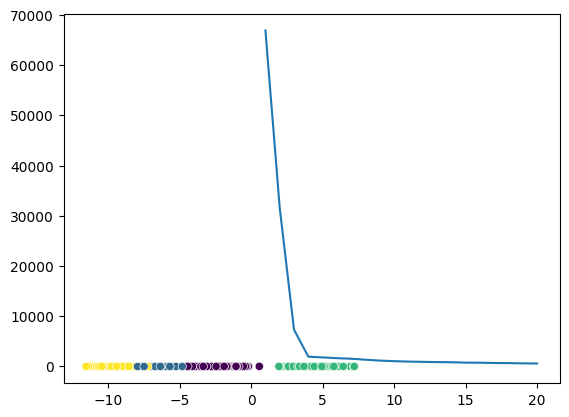

In [ ]:
#schiluotte Score
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import seaborn as sb
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
X,y=make_blobs(
    n_features=2,
    n_samples=1000,
    centers=4,
    random_state=42
)

sb.scatterplot(
    x=X[:,0],y=X[:,1]
)
wcss=[]
for i in range(1,21):
    kmeans=KMeans(
        n_clusters=i,
        random_state=42
    )
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
    
knee=KneeLocator(
    range(1,21),
    wcss,
    curve="convex",
    direction="decreasing"
)
print(knee.elbow)
sb.lineplot(x=range(1,21),y=wcss,markers="o")
kmeans=KMeans(
    n_clusters=knee.elbow,
    random_state=42
)

labels=kmeans.fit_predict(X)
sb.scatterplot(
    x=X[:,0],y=X[:,1],c=labels
)

score=silhouette_score(X,labels)
print(score)